# this is a mini MVA project 

In [13]:
import pandas as pd 
import numpy as np
import pingouin as pg
import matplotlib.pyplot as plt  

In [4]:
df = pd.read_csv('D:\Ahmed\K_repo\project555\data\HATCO_clean.csv')
df.head()

<>:1: SyntaxWarning: invalid escape sequence '\A'
<>:1: SyntaxWarning: invalid escape sequence '\A'
C:\Users\DUBAI STORE\AppData\Local\Temp\ipykernel_3684\2007023382.py:1: SyntaxWarning: invalid escape sequence '\A'
  df = pd.read_csv('D:\Ahmed\K_repo\project555\data\HATCO_clean.csv')


,id,delivery_speed,price_level,price_flexibility,manufacturer_image,service_level,salesforce_image,product_quality,firm_size,usage_level,satisfaction,spec_buying,procurement_structure,industry_type,buying_situation
0,1,4.1,0.6,6.9,4.7,2.4,2.3,5.2,0,32,4.2,1,0,1,1
1,2,1.8,3.0,6.3,6.6,2.5,4.0,8.4,1,43,4.3,0,1,0,1
2,3,3.4,5.2,5.7,6.0,4.3,2.7,8.2,1,48,5.2,0,1,1,2
3,4,2.7,1.0,7.1,5.9,1.8,2.3,7.8,1,32,3.9,0,1,1,1
4,5,6.0,0.9,9.6,7.8,3.4,4.6,4.5,0,58,6.8,1,0,1,3


## report the raw data stats

In [ ]:
from ydata_profiling import ProfileReport

profile = ProfileReport(df, title="Profiling Report")
profile.to_file("your_report.html")

<>:3: SyntaxWarning: invalid escape sequence '\A'
<>:3: SyntaxWarning: invalid escape sequence '\A'
C:\Users\DUBAI STORE\AppData\Local\Temp\ipykernel_3684\2019254043.py:3: SyntaxWarning: invalid escape sequence '\A'
  df = pd.read_csv('D:\Ahmed\K_repo\project555\data\HATCO_clean.csv')


Summarize dataset:   0%|          | 0/5 [00:00<?, ?it/s]

100%|██████████| 15/15 [00:00<00:00, 203.59it/s]


Generate report structure:   0%|          | 0/1 [00:00<?, ?it/s]

Render HTML:   0%|          | 0/1 [00:00<?, ?it/s]

Export report to file:   0%|          | 0/1 [00:00<?, ?it/s]

### data is clean and ready for the tests

## 1st question: is the client scale affect the satisfaction level?

### 📌 RQ1: Firm Size vs. Satisfaction

**Question:** Does average satisfaction (`X10`) differ significantly by firm size (`X8`)?

**Test:** One-Way ANOVA

**Variables:**
* **IV:** `X8` (Firm Size) [0 = Small, 1 = Large]
* **DV:** `X10` (Satisfaction Level) [Scale: 0–10]

**Hypotheses:**
* **$H_0$:** $\mu_{large} = \mu_{small}$ (No difference)
* **$H_1$:** $\mu_{large} \neq \mu_{small}$ (Difference exists)

**Steps:**
1. **Normality:** Shapiro-Wilk Test.
2. **Homogeneity of Variance:** Levene's Test. cause we compair 2 vars.
3. **Execution:** Run One-Way ANOVA and evaluate the *P-value*.

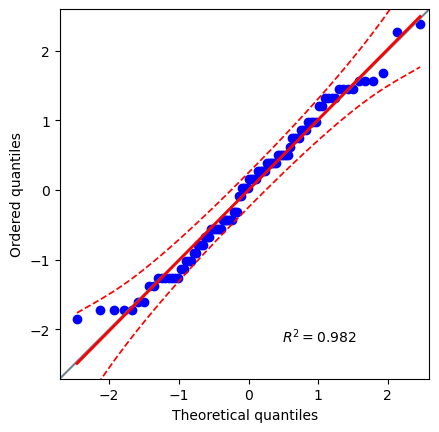

                    W      pval  normal
satisfaction  0.97675  0.073995    True


In [38]:
# test normalty of DV 
%matplotlib inline
ax = pg.qqplot(df["satisfaction"], dist='norm')
plt.show()
print(pg.normality(df["satisfaction"]))   #H0: DV is in N.Dist                                 # Univariate normality

In [ ]:
# homogeneity test, H0: DV is homogenies
pg.homoscedasticity(data=df, dv='satisfaction', group='firm_size')

,W,pval,equal_var
levene,0.194206,0.66041,True


In [31]:
# H0: mean of small size firms satisfaction = the big size satisfaction
pg.anova(data=df, dv="satisfaction" ,between='firm_size', detailed=False)

,Source,ddof1,ddof2,F,p_unc,np2
0,firm_size,1,98,25.806747,0.000002,0.208444


### 📊 Step 3 — One-Way ANOVA Result

| Source | F-statistic | p-value | Decision |
|---|---|---|---|
| firm_size | 25.8067 | < 0.001 | ✅ Reject H₀ |

**Interpretation:**
- F = 25.81 is very large → there is a strong group effect
- p < 0.001 → the difference is **statistically significant** at α = 0.05

**Conclusion:**
Large firm have significantly **defference mean** than Small firms.



## 2nd question: Does the client scale affect multiple performance metrics simultaneously?

### 📌 RQ2: Firm Size vs. Performance Perceptions

**Question:** Do the average performance perceptions (e.g., `X1` Delivery Speed, `X2` Price Level, `X3` Price Flexibility) differ significantly based on firm size (`X8`)?

**Test:** One-Way MANOVA (Multivariate Analysis of Variance)

**Variables:**
* **IV:** `X8` (Firm Size) [Categorical: e.g., 0 = Small, 1 = Large]
* **DVs:** `X1`, `X2`, `X3`, etc. (Multiple Performance Perceptions) [Continuous Scale: 0–10]

**Hypotheses:**
* **$H_0$:** $\boldsymbol{\mu}_{large} = \boldsymbol{\mu}_{small}$ (No difference in the *mean vectors* across groups)
* **$H_1$:** $\boldsymbol{\mu}_{large} \neq \boldsymbol{\mu}_{small}$ (Difference exists in the mean vectors; firm size affects at least one of the perceptions)

**Steps:**
1. **Multivariate Normality:** Mardia's Test (or Shapiro-Wilk for each DV).
2. **Homogeneity of Covariance Matrices:** Box's M Test (This is the MANOVA equivalent of Levene's test, used because we are now comparing a matrix of multiple variables, not just one).
3. **Homogeneity of Variance:** Levene's Test (for each DV individually).
4. **Execution:** Run MANOVA and evaluate the *P-value* using multivariate statistics like **Wilks' Lambda** or **Pillai's Trace**.

##### "Why not just run 3 separate ANOVAs instead?"
You might be thinking: "If I have 3 DVs, why not just run 3 simple ANOVAs (one for Speed, one for Price, one for Flexibility)?" There are two massive reasons why Data Scientists use MANOVA instead:

To stop "False Positives" (Type I Error): Every time you run a statistical test, there is a 5% chance of getting a false positive. If you run 3 separate ANOVAs, your error rate balloons from 5% to nearly 15%! MANOVA tests all three at once, keeping your overall error rate locked at a safe 5%.

Variables are connected: Delivery Speed and Price Level are probably correlated (e.g., faster delivery usually means higher prices). Separate ANOVAs are blind to this connection. MANOVA combines the DVs into a new "super-variable" (a mathematical vector) and analyzes them together, respecting their correlations.

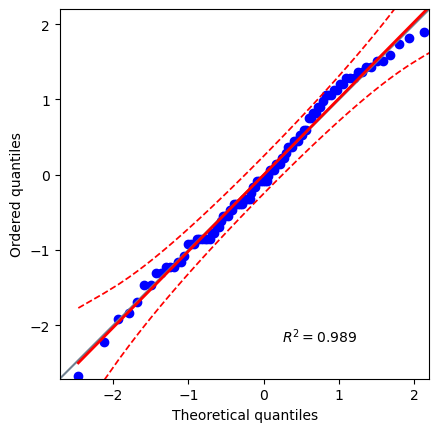

                       W      pval  normal
delivery_speed  0.985425  0.340633    True


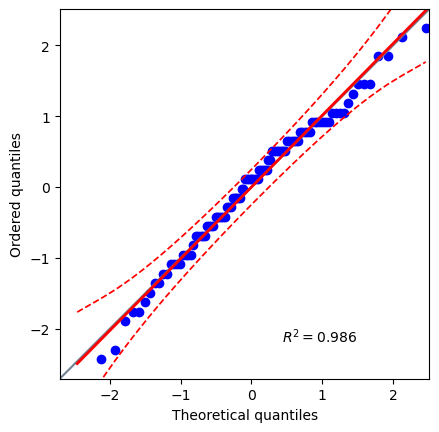

                      W      pval  normal
service_level  0.985861  0.365702    True


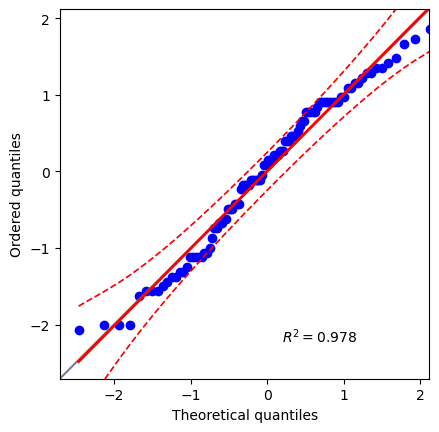

                        W      pval  normal
product_quality  0.971366  0.028151   False


In [39]:
# test multi normality 
Iv= df["firm_size"]
Dvs= ["delivery_speed","service_level","product_quality"]

%matplotlib inline

for i in Dvs :
    ax = pg.qqplot(df[i], dist='norm')
    plt.show()
    print(pg.normality(df[i]))   #H0: DV is in N.Dist                                 # Univariate normality

### will need to take care of the product_quality in the test as it not in N.dist

In [49]:
for i in Dvs:
    print(f"{i} homoscedasticity result: \n {pg.homoscedasticity(data=df, dv=i, group='firm_size')} \n\n")

delivery_speed homoscedasticity result: 
                W      pval  equal_var
levene  0.993002  0.321464       True 


service_level homoscedasticity result: 
                W      pval  equal_var
levene  6.741075  0.010871      False 


product_quality homoscedasticity result: 
               W      pval  equal_var
levene  9.17839  0.003131      False 




In [50]:
print(df['firm_size'].value_counts())

firm_size
0    60
1    40
Name: count, dtype: int64
